<a href="https://colab.research.google.com/github/andrigerber/Adv_GenAI/blob/main/Step_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

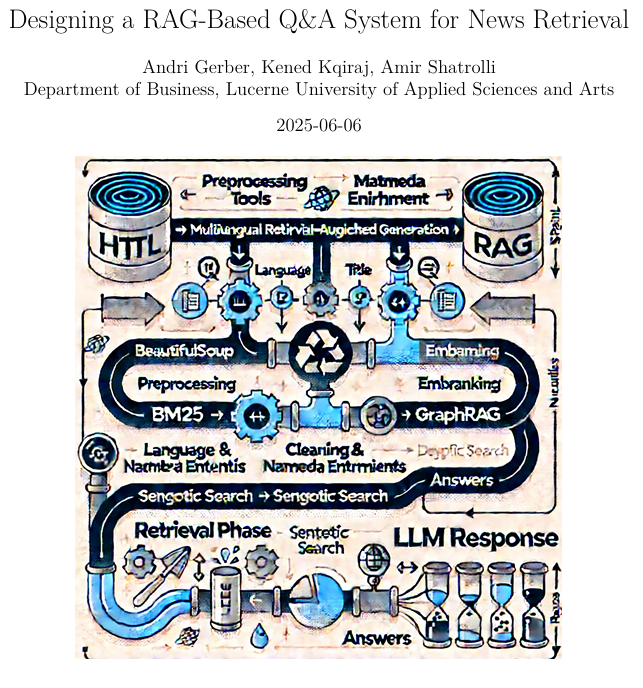


----
<h1 style="font-size:2.7em; margin-bottom:0.5em;">Author Contributions</h1>
<table style="
  width: 100%;
  border-collapse: collapse;
  font-family: 'Segoe UI', Arial, sans-serif;
  font-size: 2em;
  ">
  <thead>
    <tr>
      <th style="
        border-bottom: 4px solid #222;
        text-align: left;
        padding: 28px 20px 20px 20px;
        background-color: #f7f7f7;
        font-size: 1.25em;
        letter-spacing: 0.02em;
        ">Name</th>
      <th style="
        border-bottom: 4px solid #222;
        text-align: left;
        padding: 28px 20px 20px 20px;
        background-color: #f7f7f7;
        font-size: 1.25em;
        letter-spacing: 0.02em;
        ">Contribution Description</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="border-bottom: 3px solid #bbb; padding: 24px 20px;"><strong>Andri Gerber</strong></td>
      <td style="border-bottom: 3px solid #bbb; padding: 24px 20px;">Developed the codebase, prepared the documentation/report.</td>
    </tr>
    <tr>
      <td style="border-bottom: 3px solid #bbb; padding: 24px 20px;"><strong>Kened Kqiraj</strong></td>
      <td style="border-bottom: 3px solid #bbb; padding: 24px 20px;">Reviewed the code and report, and provided feedback.</td>
    </tr>
    <tr>
      <td style="border-bottom: 3px solid #bbb; padding: 24px 20px;"><strong>Amir Shatrolli</strong></td>
      <td style="border-bottom: 3px solid #bbb; padding: 24px 20px;">Reviewed the code and report, and provided feedback.</td>
    </tr>
  </tbody>
</table>

---


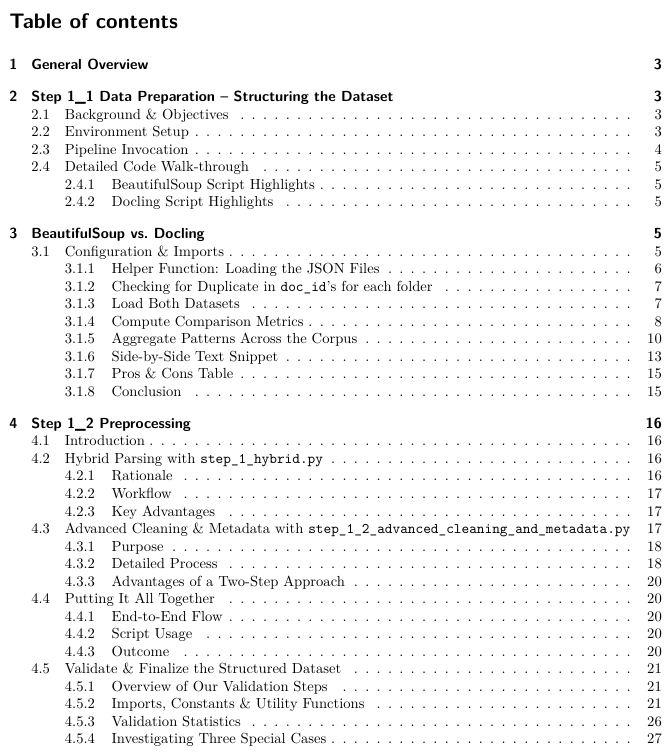


# General Overview
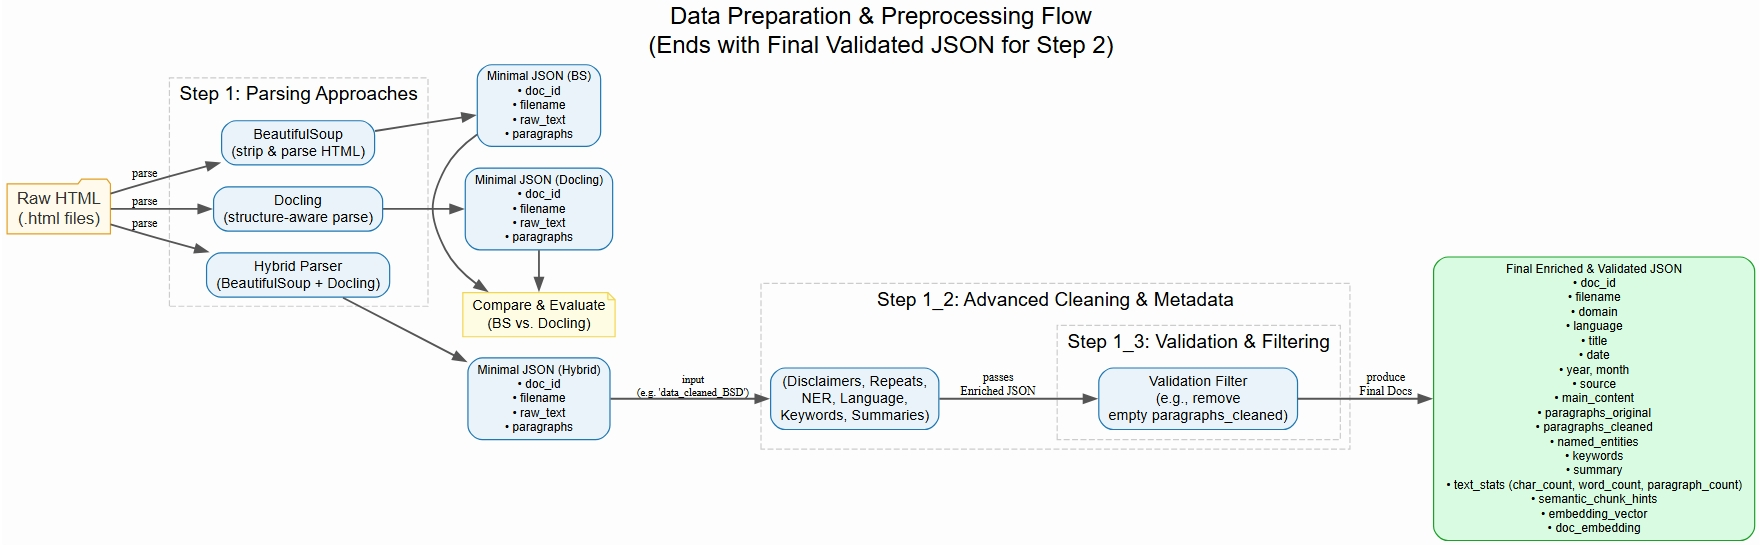


# Step 1_1 Data Preparation – Structuring the Dataset



## Background & Objectives
In retrieval‑augmented generation (RAG), the quality of retrieved documents directly influences answer accuracy. Hence:

1. Clean extraction of text from HTML is critical
2. Preserving structure (headings, paragraphs, tables) can improve downstream chunking and retrieval
3. We compare two parsing strategies:

    - **BeautifulSoup**: tag‑stripping, minimal dependencies

    - **Docling**: semantic parsing, structure‑aware, boilerplate removal

**Goals**

- Extract & normalize news articles in German & English
- Annotate each with `doc_id`, `filename`, `raw_text`, and `paragraphs`
- Evaluate output quality via character/word/paragraph counts and a token‑based Jaccard metric
- Determine which parser is best for a production RAG pipeline



## Environment Setup
We isolate dependencies to avoid conflicts and ensure reproducibility. Create a virtual environment python 3.11 and install the required libraries.

```bash
# 1) Activate your virtual environment
.venv\Scripts\activate
```

```bash
# 2) Install libraries
pip install bs4
pip install docling
pip install dateparser
pip install yake
pip install lingua-language-detector
pip install spacy
pip install nltk
```

```bash
# 3) Download models for spaCy and NLTK for Step 1_2
python -m spacy download en_core_web_sm
python -m spacy download de_core_news_sm
python -m nltk.downloader punkt
```
**Why two parsers?**

- [BeautifulSoup](https://beautiful-soup-4.readthedocs.io/en/latest/) is ubiquitous, very fast, and ideal for quick “all‑visible text” extraction.
- [Docling](https://github.com/docling-project/docling) uses layout analysis to retain headings, drop nav bars, and collapse boilerplate—valuable for clean segmentation.

## Pipeline Invocation
Assuming your raw HTML lives under `data/`, run:

**1. BeautifulSoup**
usage: `python step_1_BeautifulSoup.py [input_folder] [output_folder]`

```bash
python Code/step_1_BeautifulSoup.py data data_cleaned/data_cleaned_BS
```
**2. Docling**
usage: `python step_1_Docling.py [input_folder] [output_folder]`

```bash
python Code/step_1_Docling.py data data_cleaned/data_cleaned_D
```
Once these scripts finish, you should have two sets of JSON files:

- `data_cleaned_BS/`: output from the BeautifulSoup approach
- `data_cleaned_D/`: output from the Docling approach

Each script:

- Recursively finds .html
- Assigns a deterministic `doc_id` (SHA‑1 of the relative path)
- Emits a JSON per document containing:

```json
{
  "doc_id": "...",
  "filename": "...",
  "raw_text": "…normalized text…",
  "paragraphs": [ "para 1", "para 2", … ]
}
```
- Logs progress and errors

## Detailed Code Walk‑through



### BeautifulSoup Script Highlights
- [`step_1_BeautifulSoup.py`](https://github.com/andrigerber/Adv_GenAI/blob/main/Code/step_1_BeautifulSoup.py):
    - **Tag removal**: We proactively drop elements known to contain non‑article content.
    - **Normalization**: `unicode` NFC + strip blank lines.
    - **Paragraph split**: Split on two or more newlines, fallback to single‑line paragraphs if only one chunk remains.



### Docling Script Highlights
- [`step_1_Docling.py`](https://github.com/andrigerber/Adv_GenAI/blob/main/Code/step_1_Docling.py):
    - **DocumentConverter** analyzes layout, extracts headings, captions, and body text.
    - **`export_to_text()`** yields a structured plain‑text representation (including `##` headings).

**Trade‑off**: Docling startup is heavier (Java + layout libs), but output is cleaner.



# BeautifulSoup vs. Docling
In this section, we perform a comprehensive comparison of two HTML‑parsing pipelines—**BeautifulSoup** and **Docling**—to assess their output quality for downstream Retrieval‑Augmented Generation (RAG). We load the cleaned JSON outputs, compute a suite of metrics on **4,388** shared documents, visualize corpus‑wide trends, examine a representative text snippet, and conclude with detailed pros & cons.



## Configuration & Imports

```bash
# Install libraries for comparison
pip install matplotlib
pip install seaborn
pip IPython
```

In [ ]:
import argparse
import json
import logging
import re
from pathlib import Path
from typing import Dict, Set, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from collections import defaultdict

# Enable inline plotting
%matplotlib inline

#–– CLI/config scaffolding ––
parser = argparse.ArgumentParser(
    description="Compare BeautifulSoup vs Docling parsing outputs."
)
parser.add_argument(
    "--bs-dir",
    type=Path,
    default=Path("../data_cleaned/data_cleaned_BS"),
    help="Directory for BS JSON outputs",
)
parser.add_argument(
    "--dc-dir",
    type=Path,
    default=Path("../data_cleaned/data_cleaned_D"),
    help="Directory for Docling JSON outputs",
)
args, _ = parser.parse_known_args()

#–– Logging ––
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s %(levelname)s %(message)s",
    datefmt="%H:%M:%S"
)
logger = logging.getLogger("compare_parsers")

#–– Matplotlib Defaults ––
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})
COLOR_BS = "#1f77b4"  # blue
COLOR_DOCL = "#d62728"  # red
COLOR_JACC = "#2ca02c"  # green

**Note:** Adjust the default paths (`--bs-dir`, `--dc-dir`) as needed to point to your actual data folders.

### Helper Function: Loading the JSON Files

We'll load all JSON files in each directory into a Python dictionary keyed by `doc_id`.

In [ ]:
## 2. Helper Functions for Loading JSON
def list_duplicates(json_dir: Path):
    """
    Returns a dict mapping doc_id -> list of Paths,
    including only those with more than one file.
    """
    mapping = defaultdict(list)
    for path in json_dir.rglob("*.json"):
        if not path.is_file():
            continue
        try:
            data = json.loads(path.read_text(encoding="utf-8"))
            doc_id = data.get("doc_id", path.stem)
        except Exception:
            # skip broken JSON
            continue
        mapping[doc_id].append(path)
    # filter to duplicates
    return {doc_id: paths for doc_id, paths in mapping.items() if len(paths) > 1}

def load_json_outputs(json_dir: Path) -> Dict[str, dict]:
    """
    Recursively find all .json paths under `json_dir`, then
    only attempt to read those that still exist. Returns
    a mapping doc_id → loaded JSON dict.
    """
    # 1) Gather all .json paths:
    paths = list(json_dir.rglob("*.json"))
    logger.info(f"Discovered {len(paths)} JSON paths under {json_dir!r}")

    results: Dict[str, dict] = {}
    for path in tqdm(paths, desc=f"Loading JSON from {json_dir.name}"):
        # 2) Skip if missing
        if not path.is_file():
            logger.warning(f"  • Skipping missing file: {path}")
            continue

        # 3) Attempt to parse
        try:
            raw = path.read_text(encoding="utf-8")
            data = json.loads(raw)
            doc_id = data.get("doc_id", path.stem)
            results[doc_id] = data
        except json.JSONDecodeError as e:
            logger.warning(f"  • Invalid JSON in {path.name}: {e}")
        except Exception as e:
            logger.warning(f"  • Error reading {path.name}: {e}")

    logger.info(f"Loaded {len(results)} / {len(paths)} documents from {json_dir.name}")
    return results

## 🔧 Helper Functions for JSON Loading

- `list_duplicates(json_dir: Path)`:  
  Scans a directory for `.json` files, reads their `doc_id`, and returns a dictionary of duplicated `doc_id`s (those that appear in more than one file).

- `load_json_outputs(json_dir: Path)`:  
  Recursively loads all `.json` files under the given directory. Returns a dictionary mapping `doc_id` → loaded JSON content. Skips unreadable or missing files and logs warnings.

Both functions help manage and inspect raw JSON outputs by checking for duplicates and loading valid data only.


### Checking for Duplicate in `doc_id`'s for each folder

In [ ]:
# Find and print duplicates in each folder
bs_dupes = list_duplicates(args.bs_dir)
dc_dupes = list_duplicates(args.dc_dir)

print(f"→ BeautifulSoup folder: {len(bs_dupes)} duplicate doc_ids\n")
for doc_id, paths in list(bs_dupes.items())[:5]:
    print(f"  • {doc_id!r}:")
    for p in paths:
        print(f"      - {p}")
print("  …\n")

print(f"→ Docling folder: {len(dc_dupes)} duplicate doc_ids\n")
for doc_id, paths in list(dc_dupes.items())[:5]:
    print(f"  • {doc_id!r}:")
    for p in paths:
        print(f"      - {p}")
print("  …")

→ BeautifulSoup folder: 0 duplicate doc_ids

  …

→ Docling folder: 0 duplicate doc_ids

  …


🔍 Checking for Duplicate `doc_id`s

This step scans both the BeautifulSoup and Docling output folders for duplicate `doc_id`s.

- Uses `list_duplicates()` to detect if any `doc_id` appears in more than one file.
- Prints the total count of duplicate IDs per folder.
- Displays up to 5 examples (if found) with the paths of the duplicates.

Result: No duplicate `doc_id`s were found in either folder.


### Load Both Datasets

In [ ]:
## Robust Loader with Existence Check
bs_data = load_json_outputs(args.bs_dir)
dc_data = load_json_outputs(args.dc_dir)

common_ids = sorted(set(bs_data).intersection(dc_data))
logger.info(f"Found {len(common_ids)} documents in common between BS & Docling.")

INFO: Discovered 4390 JSON paths under WindowsPath('../data_cleaned/data_cleaned_BS')
Loading JSON from data_cleaned_BS: 100%|██████████| 4390/4390 [00:07<00:00, 562.87it/s]
INFO: Loaded 4388 / 4390 documents from data_cleaned_BS
INFO: Discovered 4390 JSON paths under WindowsPath('../data_cleaned/data_cleaned_D')
Loading JSON from data_cleaned_D: 100%|██████████| 4390/4390 [00:06<00:00, 713.40it/s]
INFO: Loaded 4388 / 4390 documents from data_cleaned_D
INFO: Found 4388 documents in common between BS & Docling.


**Result**: A total of 4,388 documents were successfully parsed by both pipelines, and no duplicate `doc_ids` were found in either output directory. We generated these doc_ids (via a SHA‑1 hash of each file’s relative path) because the original HTML filenames weren’t globally unique across the English and German folders. We will later apply an automated deduplication step in our final hybrid parser to filter out duplicate or boilerplate paragraphs, ensuring each JSON contains only unique, non‑redundant content.

### Compute Comparison Metrics

For each document, we calculate four metrics to quantify and compare the HTML‑parsing outputs:

- **Character count**: the total number of characters in the extracted text.  
- **Word count**: the total number of whitespace‑delimited tokens (words).  
- **Paragraph count**: the number of segments produced by our paragraph‑splitting logic.  
- **Token‑level Jaccard similarity**: a set‑based measure of overlap between the unique tokens from BeautifulSoup and Docling.

Let  
$$
T_{\mathrm{BS}} = \{\text{unique tokens from BeautifulSoup output}\},\quad
T_{\mathrm{Doc}} = \{\text{unique tokens from Docling output}\}.
$$

The **Jaccard similarity** \(J\) is then defined as:

$$
J(T_{\mathrm{BS}},\,T_{\mathrm{Doc}})
\;=\;
\frac{\bigl|T_{\mathrm{BS}} \cap T_{\mathrm{Doc}}\bigr|}
     {\bigl|T_{\mathrm{BS}} \cup T_{\mathrm{Doc}}\bigr|},
$$

where the numerator counts tokens common to both sets and the denominator counts all tokens present in either set. Values range from 0 (no overlap) to 1 (identical token sets)  [[1](https://studymachinelearning.com/jaccard-similarity-text-similarity-metric-in-nlp/?utm_source=chatgpt.com), [2](https://billchambers.me/posts/tf-idf-explained-in-python?utm_source=chatgpt.com)].


In [ ]:
## 5. Comparing Character, Word, Paragraph Counts + Jaccard Similarity
TOKEN_RE = re.compile(r"\w+", re.UNICODE)

def tokenize(text: str) -> Set[str]:
    """Lower-case alphanumeric tokens for Jaccard similarity."""
    return set(TOKEN_RE.findall(text.lower()))

def compute_metrics(bs_json: dict, docling_json: dict) -> Tuple[int, int, int, int, int, int, float]:
    """
    Compute a set of comparison metrics:
      - BS chars, Docling chars
      - BS words, Docling words
      - BS paragraph count, Docling paragraph count
      - Jaccard overlap of unique tokens
    """
    # Extract raw_text or fallback to paragraphs
    bs_text = bs_json.get("raw_text") or "\n".join(bs_json.get("paragraphs", []))
    dc_text = docling_json.get("raw_text") or "\n".join(docling_json.get("paragraphs", []))

    bs_chars = len(bs_text)
    dc_chars = len(dc_text)
    bs_words = len(bs_text.split())
    dc_words = len(dc_text.split())
    bs_pars  = len(bs_json.get("paragraphs", []))
    dc_pars  = len(docling_json.get("paragraphs", []))

    # Token-based Jaccard
    bs_tokens = tokenize(bs_text)
    dc_tokens = tokenize(dc_text)
    if not bs_tokens and not dc_tokens:
        jaccard = 1.0
    else:
        inter = bs_tokens & dc_tokens
        union = bs_tokens | dc_tokens
        jaccard = len(inter) / len(union) if union else 1.0

    return (bs_chars, dc_chars,
            bs_words, dc_words,
            bs_pars, dc_pars,
            jaccard)

# Gather metrics for each document
records = []
for doc_id in tqdm(common_ids, desc="Computing metrics"):
    rec_bs = bs_data[doc_id]
    rec_dc = dc_data[doc_id]
    (bs_chars, dc_chars,
     bs_words, dc_words,
     bs_pars, dc_pars,
     jaccard) = compute_metrics(rec_bs, rec_dc)

    records.append({
        "doc_id": doc_id,
        "bs_chars": bs_chars,      "docling_chars": dc_chars,
        "bs_words": bs_words,      "docling_words": dc_words,
        "bs_pars": bs_pars,        "docling_pars": dc_pars,
        "jaccard": jaccard
    })

Computing metrics: 100%|██████████| 4388/4388 [00:04<00:00, 962.03it/s] 


On a per-document basis, we compute the following metrics:

In [ ]:
df = pd.DataFrame(records).set_index("doc_id")
df.head(2)

,bs_chars,docling_chars,bs_words,docling_words,bs_pars,docling_pars,jaccard
doc_id,,,,,,,
001c81229e64abbf81df56919a457b8cd112ee61,6562,5949,895,761,152,38,0.828063
0026b764e2e3d7f092b448f7965c694901b1f1e7,6320,6359,850,859,98,59,0.984085


#### Statistical Summary

In [ ]:
logger.info("Summary statistics:")
df.describe().T

INFO: Summary statistics:


,count,mean,std,min,25%,50%,75%,max
bs_chars,4388.0,4144.937785,2673.224645,0.000000,1823.750000,4214.000000,5702.250000,21551.0
docling_chars,4388.0,3029.472653,2536.241213,0.000000,547.000000,2940.000000,4661.250000,22113.0
bs_words,4388.0,604.622607,393.138289,0.000000,263.000000,602.000000,836.000000,3420.0
docling_words,4388.0,439.097083,367.819041,0.000000,80.000000,422.000000,675.000000,3069.0
bs_pars,4388.0,24.738149,17.724278,0.000000,14.000000,21.000000,30.000000,195.0
docling_pars,4388.0,12.662944,9.279129,0.000000,4.000000,11.000000,18.000000,139.0
jaccard,4388.0,0.683043,0.289528,0.019874,0.445397,0.810028,0.891996,1.0


**Interpretation**:

The table shows that — on average — **BeautifulSoup** extracts **4,144.94** characters per document, whereas **Docling** extracts **3,029.47** characters, an absolute difference of 1,115.47 characters (≈ 36.8% more text in BeautifulSoup). Word counts mirror this pattern: BeautifulSoup yields **604.62** words versus **439.10** for Docling, a gain of **165.52** words (≈ 37.7% more).

However, BeautifulSoup’s naive paragraph‐splitting produces **24.74** paragraphs on average—nearly **95.5%** more than Docling’s **12.66** paragraphs—indicating a tendency to over‐segment at minor line breaks. In contrast, Docling’s output is more restrained, with roughly **27% fewer** characters and words but semantically **coherent** paragraph boundaries aligned to headings and logical breaks.

Finally, the mean **Jaccard similarity** of **0.683** implies that about **31.7%** of unique tokens differ between the two outputs, reflecting BeautifulSoup’s inclusion of boilerplate and incidental text versus Docling’s focused extraction of core content and structural markers.


### Aggregate Patterns Across the Corpus

To verify that our observed differences are not artifacts of a particular subset, we partitioned the 4,388 documents into 44 equal “bins” of ~100 documents each and plotted three key metrics for each bin (Figures: 1–3).

- **Avg Word Count (Fig.1)**: BeautifulSoup consistently yields **~530–690 words** per bin vs. **~340–510 words** for Docling, a stable gap of ~150–200 words—reflecting  BeautifulSoup’s inclusion of boilerplate and incidental text.

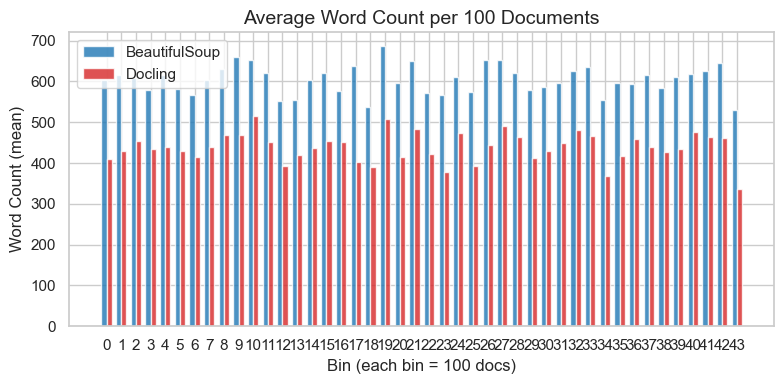

In [ ]:
# We'll create bins of size 100 docs each.
bin_size = 100

# 2) Assign a bin index to each row
df["bin"] = np.arange(len(df)) // bin_size

# 3) Compute mean values for each bin
bin_groups = df.groupby("bin").mean()

# 4) Create a bar plot
bins_index = np.arange(len(bin_groups))  # e.g. 0,1,2,... up to the number of bins
width = 0.35

plt.figure(figsize=(8,4))
plt.bar(
    bins_index - width/2,
    bin_groups["bs_words"],
    width,
    color="#1f77b4",
    alpha=0.8,
    label="BeautifulSoup",
)
plt.bar(
    bins_index + width/2,
    bin_groups["docling_words"],
    width,
    color="#d62728",
    alpha=0.8,
    label="Docling",
)

plt.title("Average Word Count per 100 Documents")
plt.xlabel("Bin (each bin = 100 docs)")
plt.ylabel("Word Count (mean)")
plt.xticks(bins_index)  # Ensures bins appear as 0,1,2,...
plt.legend()
plt.tight_layout()
plt.show()

- **Avg Paragraph Count (Fig. 2)**: BeautifulSoup produces **~20–28 paragraphs** per bin, almost double Docling’s **~10–15**, due to naive splitting on every blank line; Docling’s paragraphs align more closely with true semantic breaks.


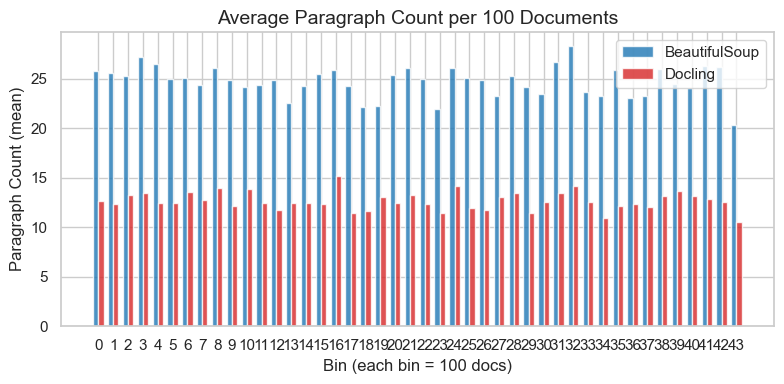

In [ ]:
# 5) Create a bar plot
plt.figure(figsize=(8,4))
plt.bar(
    bins_index - width/2,
    bin_groups["bs_pars"],
    width,
    color="#1f77b4",
    alpha=0.8,
    label="BeautifulSoup"
)
plt.bar(
    bins_index + width/2,
    bin_groups["docling_pars"],
    width,
    color="#d62728",
    alpha=0.8,
    label="Docling"
)

plt.title("Average Paragraph Count per 100 Documents")
plt.xlabel("Bin (each bin = 100 docs)")
plt.ylabel("Paragraph Count (mean)")
plt.xticks(bins_index)
plt.legend()
plt.tight_layout()
plt.show()

- **Token Overlap (Fig.3)**: Jaccard similarity stays between **~0.60–0.75** (mean ~0.68), confirming both methods share core vocabulary but differ on ~30–40% of tokens, reflecting structural and boilerplate differences.


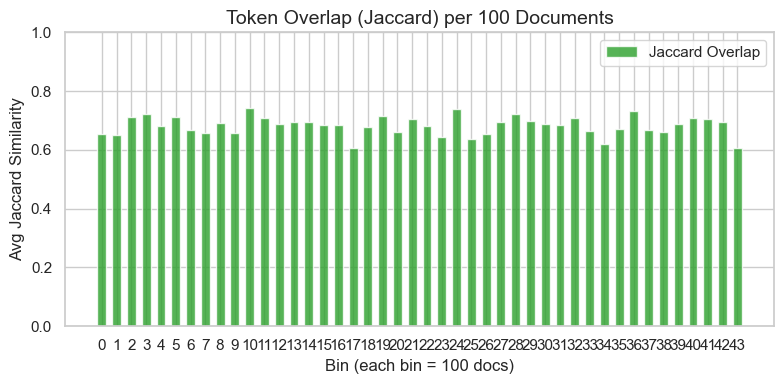

In [ ]:
plt.figure(figsize=(8,4))
plt.bar(
    bins_index,
    bin_groups["jaccard"],
    width=0.6,
    color="#2ca02c",
    alpha=0.8,
    label="Jaccard Overlap"
)

plt.title("Token Overlap (Jaccard) per 100 Documents")
plt.xlabel("Bin (each bin = 100 docs)")
plt.ylabel("Avg Jaccard Similarity")
plt.ylim(0.0, 1.0)
plt.xticks(bins_index)
plt.legend()
plt.tight_layout()
plt.show()

These patterns are uniform across the corpus, highlighting BeautifulSoup’s tendency to over‑extract/segment and Docling’s lean, structured output.  

### Side-by-Side Text Snippet
To complement our quantitative analysis, we examine how each parser renders the very beginning of one representative article (`doc_ID`:`0054c566…`). By comparing the first ~2,000 characters, we can directly observe differences in structure, completeness, and semantic cues.

In [ ]:
def show_snippet(doc_id: str, length: int = 2000):
    bs_txt = bs_data[doc_id].get("raw_text")
    dc_txt = dc_data[doc_id].get("raw_text")
    print(f"--- Document: {doc_id} ---\n")
    print("BeautifulSoup:")
    print(bs_txt[:length] + "...\n")
    print("Docling:")
    print(dc_txt[:length] + "...\n")

# Pick a representative sample
if common_ids:
    show_snippet("0054c566353942bbdd9f9c85d9cc843aad3dce97")

--- Document: 0054c566353942bbdd9f9c85d9cc843aad3dce97 ---

BeautifulSoup:
In line with the Federal Council’s easing of measures to contain the coronavirus, and in response to a proposal from the Crisis Management team, the Executive Board has decided to further relax COVID restrictions on campus and has approved the basic parameters for a new version of the master plan. This will be finalised over the coming days and is due to go live on the web on Tuesday. The easing already comes into force on Saturday, 26 June 2021 and is valid at least until mid-August. Changes include partial lifting of the general requirement to wear a face mask and permission for gatherings such as drinks receptions outdoors.
Face masks no longer compulsory outdoors
Wearing a face mask will no longer be compulsory outdoors on campus from this Saturday. However, the rule of maintaining a minimum physical distance of 1.5 metres will still apply. In situations where close contact is unavoidable (such as queuing in

1. **Lead Paragraph Omission**  
   - **Docling** excludes the opening summary on the Executive Board’s decision, possibly treating it as boilerplate metadata.  
   - **BeautifulSoup** preserves this lead, offering more complete context.

2. **Structural Cues & Heading Detection**  
   - **Docling** uses Markdown headings (`## ...`), clearly segmenting topics.  
   - **BeautifulSoup** leaves headings in plain text, requiring extra parsing for semantic boundaries.

3. **Content Continuity & Quote Handling**  
   - **Docling** captures full quotes (e.g., “comments Ulrich Weidmann”) with no mid-sentence truncation.  
   - **BeautifulSoup** cuts off (“…requir…”), reducing continuity and potentially affecting NLP tasks.

4. **Paragraph & Subtopic Grouping**  
   - **Docling** aligns text into coherent subtopic blocks, aiding clarity.  
   - **BeautifulSoup** can fragment or merge paragraphs, needing additional logic to restore structure.

5. **Downstream Workflow Considerations**  
   - **RAG Pipelines** benefit from Docling’s chunked format for precise lookups (e.g., “mask rules outdoors”).  
   - **BeautifulSoup** may need heading detection or text segmentation before advanced tasks like QA or summarization.

6. **Strategic Implications**  
   - Clean, well-segmented text often outperforms raw extracts in NLP tasks.  
   - **BeautifulSoup** provides faithful raw HTML parsing.  
   - **Docling**’s structured output reduces post-processing overhead and improves retrieval accuracy.

Overall, **Docling** returns more structured, context-rich text, while **BeautifulSoup** stays closer to the raw HTML.


### Pros & Cons Table

Below is a concise comparison of **BeautifulSoup** and **Docling**, reflecting key findings from the parsing experiments. In total, **4,390** HTML files were processed, with **BeautifulSoup** completing its run in **18.53 seconds** and **Docling** in **95.82 seconds**.

| **Aspect**               | **BeautifulSoup**                                                                              | **Docling**                                                                                                                     |
|--------------------------|------------------------------------------------------------------------------------------------|---------------------------------------------------------------------------------------------------------------------------------|
| **Parsing Speed**        | **Faster** startup and execution; took **18.53s** for 4,390 HTML files                         | **Slower** initialization and runtime; took **95.82s** for 4,390 HTML files                                                    |
| **Dependencies**         | Lightweight (pure Python)                                                                      | Heavier (Java + layout libraries)                                                                                              |
| **Content Coverage**     | Includes more boilerplate; rarely misses lead paragraphs                                       | May omit some lead or “boilerplate” content                                                                                    |
| **Paragraph Structure**  | Splits on blank lines, leading to fragmented or excessive paragraphs                           | Groups logically related sentences, using headings and subheadings for coherent segmentation                                   |
| **Quote & Heading**      | Potential for partial quotes if HTML breaks unexpectedly; headings appear as plain text        | Preserves quotations more reliably; injects `## Headings` to mark new sections                                                 |
| **Downstream Utility**   | Output often needs extra cleaning (merge paragraphs, detect headings) for advanced QA/summar. | Already chunked by headings/subtopics; minimal extra cleaning required for RAG or summarization                                |
| **Overall Output**       | Raw HTML extraction stays close to original structure, but can be messy                        | Clean, structured text with more semantic detail, but risks omitting lead or navigational segments                             |

### Conclusion

Both parsers successfully extract content from HTML but serve different needs:

- **BeautifulSoup** excels at **fast**, broad HTML extraction. Its familiarity and low overhead make it ideal for quick data ingestion. However, it often includes boilerplate text and requires additional processing to remove noise and properly segment paragraphs.
- **Docling** produces **structured, context-rich text** with headings and coherent paragraph grouping. While it has a longer startup time (95.82s vs. 18.53s for BeautifulSoup) and can omit lead content it classifies as boilerplate, its output requires less manual cleanup for advanced NLP tasks such as RAG-based QA or summarization.

A combined **hybrid approach**—using BeautifulSoup for robust parsing and Docling’s semantic structure—will likely be the most effective way to ensure both data **completeness** and **high‑quality structure** in our RAG system.

# Step 1_2 Preprocessing




## Introduction
This phase of our pipeline converts raw HTML files into structured JSON documents suitable for advanced Retrieval‑Augmented Generation (RAG) tasks. It consists of two primary steps:

1. A **hybrid parsing** script ([`step_1_hybrid.py`](https://github.com/andrigerber/Adv_GenAI/blob/main/Code/step_1_hybrid.py)) that combines the strengths of BeautifulSoup and Docling.  
2. An **advanced cleaning and metadata** script ([`step_1_2_advanced_cleaning_and_metadata.py`](https://github.com/andrigerber/Adv_GenAI/blob/main/Code/step_1_2_advanced_cleaning_and_metadata.py)) that refines paragraphs, removes repeated boilerplate, and enriches each document with linguistic annotations.

By the end of Step 1_2, we obtain high‑quality, fully annotated text that can be indexed and chunked for downstream applications such as QA systems or summarization pipelines.

---



## Hybrid Parsing with [`step_1_hybrid.py`](https://github.com/andrigerber/Adv_GenAI/blob/main/Code/step_1_2_advanced_cleaning_and_metadata.py)



### Rationale
In order to ensure both breadth of HTML coverage and meaningful structural segmentation, **BeautifulSoup** and **Docling** are run in tandem:

- **BeautifulSoup** removes top-level non‑article tags—such as `<script>`, `<style>`, `<nav>`, and `<aside>`—resulting in simpler HTML.  
- **Docling** then performs deeper layout analysis on this simplified HTML, retaining headings, subheadings, and logical paragraph boundaries that might be missed by naive parsing approaches.



### Workflow
1. **Reading & Stripping HTML**: We read each `.html` file from the `input_dir`, convert it to text with minimal tag removal, and clean up certain boilerplate elements (e.g., scripts, headers).  
2. **Docling Extraction**: The cleaned HTML is fed into Docling, which captures structural cues (like headings or subtopic blocks).  
3. **Normalization & Paragraph Splitting**: We normalize all Unicode characters, remove empty lines, and split the text into paragraphs either on blank lines or per line as a fallback.  
4. **Output**: The script writes a minimal JSON record for each document containing:
   - **`doc_id`** (SHA‑1 hash of the file’s relative path),
   - **`filename`**,
   - **`raw_text`** (entire cleaned text),
   - **`paragraphs`** (a naive paragraph list).
   
    ```json
    {
      "doc_id": "774f...",
      "filename": "name...",
      "raw_text": "…normalized text…",
      "paragraphs": [ "para 1", "para 2", … ]
    }
    ```


### Key Advantages
- **Balanced Coverage**: By removing only obvious non-content tags, we preserve critical text while eliminating distracting HTML structures.  
- **Structured Paragraphs**: Docling’s layout analysis often yields cleaner paragraph boundaries than naive splitting, minimizing the risk of incomplete or merged paragraphs.  
- **Lightweight Output**: This script does not perform advanced tasks such as language detection or boilerplate disclaimers removal, keeping it minimal and fast for large HTML dumps.

---



## Advanced Cleaning & Metadata with [`step_1_2_advanced_cleaning_and_metadata.py`](https://github.com/andrigerber/Adv_GenAI/blob/main/Code/step_1_2_advanced_cleaning_and_metadata.py)

> **Metadata extraction** can be handled end-to-end by an LLM (e.g., LlamaIndex’s [MetadataExtractor](https://docs.llamaindex.ai/en/stable/examples/metadata_extraction/MetadataExtraction_LLMSurvey/)), which outputs language, dates, entities, keywords, and summaries in a single call—but with increased latency, cost, and risk of hallucinations. Instead, we use a **two-step pipeline**. In **step one**, we apply a fully rule-based approach to the entire corpus: hybrid BeautifulSoup + Docling parsing strips boilerplate and reconstructs structure, followed by deterministic tools (dateparser, Lingua, spaCy, YAKE) and an optional summary, yielding reproducible, spec-compliant JSON fields (language, title/date/source, named entities, keywords, summary, text stats, etc.).
>
> **All metadata extraction in this notebook is strictly rule-based for efficiency and transparency.**
>
> In **step\_2\_1** (see section: *LLM-Based Metadata Extraction for Subsampled Chunks*, [2_1_llm_metadataextraction.py](https://github.com/andrigerber/Adv_GenAI/blob/main/Code/2_1_llm_metadataextraction.py)), we generate a subsample for Q\&A benchmarking, and here we apply **LLM-based metadata extraction**—not using LlamaIndex’s MetadataExtractor, but our own implementation with OpenAI and Pydantic. This is feasible only at subsample scale and allows us to extract structured fields (summaries, event dates, roles, topics, etc.) that go beyond the limits of rule-based tools.

### Purpose
After generating minimal JSON from the hybrid parser, this second step refines and enriches the text further. Our goals include:

1. **Disclaimers & Footer Removal**: Eliminate lines that match known regex patterns (e.g., “Staffnet,” “Subscribe to Newsletter,” footers, disclaimers).  
2. **Frequency-Based Boilerplate Removal**: Identify paragraphs repeated across many documents (e.g., repeated footers) and remove them if they exceed a predefined threshold.  
3. **Metadata Extraction**: Add valuable fields (language codes, named entities, keywords, etc.) to each document.



### Detailed Process



#### Boilerplate Stripping
The script first reads all JSON files output from `step_1_hybrid.py`. For each paragraph, we split it into lines, match each line against a list of **regex patterns** representing disclaimers or repeated boilerplate, and discard any matches. This produces a “refined” set of paragraphs per document.

Example regex patterns include:

```python
BOILERPLATE_PATTERNS = [
    r"Staffnet",
    r"Newsletter\sabonnieren",
    r"call_made",
    ...]
```



#### Frequency Dictionary & Thresholding
We then build a **frequency dictionary** of refined paragraphs across all documents. Any paragraph occurring **≥ `--threshold`** times (default 5) is deemed boilerplate and removed from the final output. This step ensures repeated disclaimers or common footers disappear from our text corpus.



#### Enrichment: Language, Entities, Keywords, Summaries
1. **Language Detection (Lingua)**: Determines the main language of the refined text, crucial in multilingual contexts.  
2. **Date Parsing**: If applicable, extracts dates from file path structures (e.g., `2023/05`).  
3. **Named Entity Recognition (spaCy)**: Identifies names of persons, organizations, locations, etc.  
4. **Keyword Extraction (YAKE)**: Suggests key terms or phrases, facilitating topic clustering and quick lookups.  
5. **Summaries**: Generates short bullet‑style or sentence‑based summaries, providing quick glimpses of the document content.

**Note**: This can be also done via LLMs, but we opted for a less costly approach here since we are learning and not generating a production system.



#### Final JSON Output
For each document, the script writes:

- **`main_content`**: Text after disclaimers and repeated paragraphs are removed.  
- **`paragraphs_original`** & **`paragraphs_cleaned`**: Preserving both the raw paragraphs from Step 1 and the newly refined paragraphs.  
- **`named_entities`, `keywords`, `summary`**: Various NLP-enriched fields.  
- **`text_stats`**: Basic statistics (char/word/paragraph count).  
- **`semantic_chunk_hints`**: Indicating how the text might be split for downstream tasks (e.g., chunking per paragraph).

```json
{
 "doc_id": "9b7f034dc9cd5fd1b...",
 "filename": "example.html",
 "domain": "ethz.ch",
 "language": "de",
 "title": "",        //--> not implemented, we will add it in step 2_1 in the chunking section
 "date": "2023-05-01",         //--> always YYYY-MM-01
 "year": 2023,
 "month": 5,
 "source": "ETH News",        //---> always ETH News

 "main_content": "Margrit Leuthold has been the Executive ...",
 "paragraphs_original": [
    "## About the author",
        "Margrit Leuthold has been the Executive ...",
        "## Subscribe to Newsletter",
        "Subscribe to the Newsletter for internal news",
        "## Staffnet",
        "Info portal for employees ..."
],
 "paragraphs_cleaned": [
   "Margrit Leuthold has been the Executive ...",
   "... cleaned paragraph 2 if any ..."
 ],

 "named_entities": [
   {"text": "Margrit Leuthold", "label": "PERSON"},
   {"text": "ETH Zurich", "label": "ORG"}
 ],
 "keywords": ["Margrit Leuthold", "Bangalore", "Executive Director"],
 "summary": "Margrit Leuthold has been the Executive Director ...",
 "text_stats": {
   "char_count": 864,
    "word_count": 128,
    "paragraph_count": 1
 },
 "semantic_chunk_hints": [
   {"type": "paragraph_boundaries", "count": 1}
 ],
 "embedding_vector": [],
 "doc_embedding": []
}
```

### Advantages of a Two-Step Approach
- **Modularity**: Splitting hybrid parsing from advanced cleanup facilitates easier debugging and iterative refinement of cleaning heuristics.  
- **Reusability**: If disclaimers or threshold logic changes, you only need to re-run the second script—no need to re-parse the original HTML.  
- **Improved Data Quality**: Frequency-based removal and disclaimers filtering ensure final text is less cluttered, boosting retrieval accuracy and language model performance in a RAG setup.





## Putting It All Together



### End-to-End Flow
1. **Step 1: [`step_1_hybrid.py`](https://github.com/andrigerber/Adv_GenAI/blob/main/Code/step_1_hybrid.py)**  
   - Converts raw HTML → minimal JSON with partial structure.
      - Note: Takes much longer then docling or BeautifulSoup alone ~231 seconds for 4,390 files.
2. **Step 2: [`step_1_2_advanced_cleaning_and_metadata.py`](https://github.com/andrigerber/Adv_GenAI/blob/main/Code/step_1_2_advanced_cleaning_and_metadata.py)**  
   - Cleans, deduplicates, and enriches the text → final JSON.
      - Note: Takes even longer ~1126 seconds for 4,390 files.



### Script Usage
1. **Hybrid Parsing**:
   ```bash
   python step_1_hybrid.py data/ data_cleaned/data_cleaned_BSD
    ```
2. **Advanced Cleaning & Metadata**:
    ```bash
    python step_2_advanced_cleaning.py data_cleaned/data_cleaned_BSD data_cleaned/BSD_advanced --threshold 5
    ```
   


### Outcome
By the end of Step 1_2, we have an organized corpus of documents:
- Stripped of large boilerplate tags and disclaimers.
- Free of high-frequency repeated paragraphs.
- Enriched with metadata for quick indexing, querying, and RAG-based question-answering.

This two-phase solution forms a solid foundation for any subsequent NLP tasks, ensuring that every document is both comprehensive (retaining essential content) and clean (removing repetitive or irrelevant text).



## Validate & Finalize the Structured Dataset

To validate our cleaned dataset we ensure that each record:

1. **Is sufficiently informative** (i.e., not reduced to boilerplate-only).
2. **Contains all required metadata** (e.g., `doc_id`, `filename`, `paragraphs_cleaned`).

We aim to discard any documents that either have no real text or are missing mandatory fields—ultimately preserving items that have meaningful content for downstream tasks such as chunking, retrieval, or QA pipelines.





### Overview of Our Validation Steps

We will:

1. **Load** the advanced-cleaning JSON files from `../data_cleaned/BSD_advanced/`.
2. **Perform record-level validation**, checking:
   - Required fields
   - Main content (non-empty)
   - Proper paragraphs
   - Basic text statistics
3. **Generate summary statistics** at two levels:
   - **Record-level**: one row per document, indicating whether we kept or removed it.
   - **Field-level**: how many times each required field is missing or empty.
4. **Investigate three special/invalid cases**:
   - **(1)** `paragraphs_original` is empty.
   - **(2)** `paragraphs_cleaned` is empty, while `paragraphs_original` is not.
   - **(3)** Records that have *no `named_entities`* yet do have meaningful `main_content`.

Any documents that fail validation are excluded from further processing. The final set of *valid* records then becomes the basis for subsequent tasks such as embedding or QA.




### Imports, Constants & Utility Functions

In [ ]:
import json
import logging
import pandas as pd
from pathlib import Path
from pprint import pprint

REQUIRED_FIELDS = [
    "doc_id", "filename", "domain", "language", "title",
    "date", "year", "month", "source",
    "main_content", "paragraphs_original", "paragraphs_cleaned",
    "named_entities", "keywords", "summary", "text_stats"
]

def load_advanced_outputs(json_dir: Path):
    """
    Recursively loads all JSON files (from advanced cleaning) in `json_dir`,
    returning a list of record dicts.
    """
    records = []
    for path in json_dir.rglob("*.json"):
        if not path.is_file():
            continue
        try:
            data = json.loads(path.read_text(encoding="utf-8"))
            records.append(data)
        except Exception as e:
            logging.warning(f"Error reading {path}: {e}")
    return records

def validate_and_report(records):
    """
    Validates each record for required fields, main_content emptiness, etc.
    Also provides a summary per field: how many are missing/empty.

    Returns:
      valid_records: list of records that pass validation
      df_stats: a DataFrame with per-document validation details
      field_summary: a DataFrame with aggregated stats for each field
    """
    validation_stats = {
        "doc_id": [],
        "missing_fields": [],
        "char_count": [],
        "word_count": [],
        "paragraph_count_cleaned": [],
        "paragraph_count_original": [],
        "kept_or_removed": []
    }

    # We'll track how many times each required field is missing or empty
    field_summary = {
        fld: {"missing": 0, "empty": 0, "valid": 0}
        for fld in REQUIRED_FIELDS
    }

    valid_records = []
    removed_count = 0

    for rec in records:
        doc_id = rec.get("doc_id", "unknown")
        missing = [f for f in REQUIRED_FIELDS if f not in rec]

        # Prepare placeholders
        char_count = None
        word_count = None
        para_count_cleaned = None
        para_count_original = None
        kept_or_removed = "kept"

        # Check for missing fields
        if missing:
            kept_or_removed = "removed_mandatory_fields"

        # Tally missing fields
        for fld in missing:
            field_summary[fld]["missing"] += 1

        # If not missing, we can do deeper checks
        if not missing:
            # For each required field, check if it's "empty"
            for fld in REQUIRED_FIELDS:
                if fld not in rec:
                    # already accounted for in 'missing'
                    pass
                else:
                    val = rec[fld]
                    is_empty = False

                    # Decide how to define 'empty' for each type
                    if isinstance(val, str):
                        if val.strip() == "":
                            is_empty = True
                    elif isinstance(val, list) or isinstance(val, dict):
                        if len(val) == 0:
                            is_empty = True
                    elif val is None:
                        is_empty = True

                    if is_empty:
                        field_summary[fld]["empty"] += 1
                    else:
                        field_summary[fld]["valid"] += 1

            # Additional validations
            if not isinstance(rec["paragraphs_cleaned"], list):
                kept_or_removed = "removed_invalid_paragraphs"
            else:
                char_count = rec["text_stats"].get("char_count", 0)
                word_count = rec["text_stats"].get("word_count", 0)
                para_count_cleaned = len(rec.get("paragraphs_cleaned", []))
                para_count_original = len(rec.get("paragraphs_original", []))

                # If main_content empty => discard
                if char_count == 0:
                    kept_or_removed = "removed_empty_main"

        # Decide keep or remove
        if kept_or_removed != "kept":
            removed_count += 1
        else:
            valid_records.append(rec)

        # Record per-doc stats
        validation_stats["doc_id"].append(doc_id)
        validation_stats["missing_fields"].append(str(missing))
        validation_stats["char_count"].append(char_count)
        validation_stats["word_count"].append(word_count)
        validation_stats["paragraph_count_cleaned"].append(para_count_cleaned)
        validation_stats["paragraph_count_original"].append(para_count_original)
        validation_stats["kept_or_removed"].append(kept_or_removed)

    # Summarize doc-level results in a DataFrame
    df_stats = pd.DataFrame(validation_stats)

    # Build a DataFrame for field-level summary
    field_summary_rows = []
    for fld, stats_dict in field_summary.items():
        row = {"field": fld}
        row.update(stats_dict)
        field_summary_rows.append(row)
    df_field_summary = pd.DataFrame(field_summary_rows)

    logging.info(f"Kept {len(valid_records)} valid records; removed {removed_count} invalid.")
    return valid_records, df_stats, df_field_summary

# Load Data, Validate & Show Statistics
data_dir = Path("../data_cleaned/BSD_advanced")
all_records = load_advanced_outputs(data_dir)
valid_records, df_stats, df_field_summary = validate_and_report(all_records)
# TODO::Then proceed with valid_records for chunking/indexing/QA, etc.

def subset_checks(records):
    """
    Return a dictionary of subsets for different cases for validation:
      1) Documents with empty paragraphs_original
      2) Documents with empty paragraphs_cleaned but some original paragraphs
      3) Documents that have no named_entities but do have main_content
    """

    # 1) paragraphs_original is empty
    empty_pars_original = [
        r for r in records
        if len(r.get("paragraphs_original", [])) == 0
    ]

    # 2) paragraphs_cleaned is empty == main_content == '', but paragraphs_original not empty
    empty_pars_cleaned = [
        r for r in records
        if len(r.get("paragraphs_cleaned", [])) == 0
        and len(r.get("paragraphs_original", [])) > 0
    ]

    # 3) No named_entities, but main_content is not empty
    no_entities_but_content = [
        r for r in records
        if len(r.get("named_entities", [])) == 0
        and r.get("main_content", "") != ""
    ]

    return {
        "empty_pars_original": empty_pars_original,
        "empty_pars_cleaned": empty_pars_cleaned,
        "no_entities_but_content": no_entities_but_content,
    }

DESIRED_ORDER = [
    "doc_id", "filename", "domain", "language", "title", "date", "year", "month",
    "source", "main_content", "paragraphs_original", "paragraphs_cleaned",
    "named_entities", "keywords", "summary", "text_stats", "semantic_chunk_hints",
    "embedding_vector", "doc_embedding"
]

def pretty_print_record(record):
    """
    Prints the record in a strict field order defined by DESIRED_ORDER.
    If a field is missing from the record, it will appear with value=None.
    """
    ordered_dict = {field: record.get(field) for field in DESIRED_ORDER}
    print(json.dumps(ordered_dict, indent=2, ensure_ascii=False))


from pprint import pprint

def demo_empty_pars_original(subsets_adv, data_hybrid_map):
    """
    Demonstrate documents that have `paragraphs_original` empty
    (subsets_adv["empty_pars_original"]).
    Prints Hybrid record first, then Advanced-cleaned record.
    """
    print("\n------------- 1) empty_pars_original -------------")
    subset = subsets_adv["empty_pars_original"]
    if not subset:
        print("No documents found in empty_pars_original subset.")
        return

    example_doc_id_orig = subset[0]["doc_id"]
    print("Example doc_id from empty_pars_original:", example_doc_id_orig)

    # 1) Hybrid (or older step) record
    print("\n--- Hybrid (or older step) record for same doc_id ---\n")
    bsd_record = data_hybrid_map.get(example_doc_id_orig)
    if bsd_record:
        pprint(bsd_record)
    else:
        print(f"⚠️ No BSD record found for doc_id={example_doc_id_orig}")

    # 2) Advanced-cleaned record
    matching_docs_orig = [
        doc for doc in subset if doc.get("doc_id") == example_doc_id_orig
    ]
    if matching_docs_orig:
        print("\n--- Advanced-cleaned record with empty paragraphs_original ---\n")
        pretty_print_record(matching_docs_orig[0])
    else:
        print(f"No matching doc found in empty_pars_original for: {example_doc_id_orig}")


def demo_empty_pars_cleaned(
    subsets_adv,
    data_hybrid_map,
    example_doc_id_cleaned="f7af0912557c14c943098448c45563238047308f"
):
    """
    Demonstrate documents that have non-empty paragraphs_original but empty paragraphs_cleaned
    (subsets_adv["empty_pars_cleaned"]), using a specific doc_id by default for demonstration.
    Prints Hybrid record first, then Advanced-cleaned record.
    """
    print("\n------------- 2) empty_pars_cleaned -------------")
    print("Example doc_id from empty_pars_cleaned:", example_doc_id_cleaned)

    # 1) Hybrid (or older step) record
    print("\n--- Hybrid (or older step) record for same doc_id ---\n")
    bsd_record = data_hybrid_map.get(example_doc_id_cleaned)
    if bsd_record:
        pprint(bsd_record)
    else:
        print(f"⚠️ No BSD record found for doc_id={example_doc_id_cleaned}")

    # 2) Advanced-cleaned record
    matching_docs_cleaned = [
        doc for doc in subsets_adv["empty_pars_cleaned"]
        if doc.get("doc_id") == example_doc_id_cleaned
    ]
    if matching_docs_cleaned:
        print("\n--- Advanced-cleaned record with empty paragraphs_cleaned ---\n")
        pretty_print_record(matching_docs_cleaned[0])
    else:
        print(
            f"No matching doc found in empty_pars_cleaned "
            f"for doc_id={example_doc_id_cleaned}"
        )


def demo_no_entities_but_content(subsets_adv, data_hybrid_map):
    """
    Demonstrate documents that have no named_entities but do have main_content
    (subsets_adv["no_entities_but_content"]).
    Prints Hybrid record first, then Advanced-cleaned record.
    """
    print("\n------------- 3) no_entities_but_content -------------")
    subset = subsets_adv["no_entities_but_content"]
    if not subset:
        print("No documents found in no_entities_but_content subset.")
        return

    example_doc_id_entities = subset[0]["doc_id"]
    print("Example doc_id from no_entities_but_content:", example_doc_id_entities)

    # 1) Hybrid (or older step) record
    print("\n--- Hybrid (or older step) record for same doc_id ---\n")
    bsd_record = data_hybrid_map.get(example_doc_id_entities)
    if bsd_record:
        pprint(bsd_record)
    else:
        print(f"⚠️ No BSD record found for doc_id={example_doc_id_entities}")

    # 2) Advanced-cleaned record
    matching_docs_entities = [
        doc for doc in subset if doc.get("doc_id") == example_doc_id_entities
    ]
    if matching_docs_entities:
        print("\n--- Advanced-cleaned record with no named_entities but has main_content ---\n")
        pretty_print_record(matching_docs_entities[0])  # BUG FIX: use correct list
    else:
        print(f"No matching doc found in no_entities_but_content for doc_id={example_doc_id_entities}")

INFO: Kept 3544 valid records; removed 844 invalid.


### Validation Statistics

- **Record-level stats (`df_stats`)**: Each document has a row. We can see if a document was kept or removed, plus its text lengths, paragraph counts, etc.

In [ ]:
display(df_stats.head(2))

,doc_id,missing_fields,char_count,word_count,paragraph_count_cleaned,paragraph_count_original,kept_or_removed
0,774f211191019b729ccab161cd79cbac75415788,[],896,116,1,6,kept
1,b8e9a4eedc8255f0e7db76909ac8ce178529d805,[],0,0,0,4,removed_empty_main


- **Field-level summary (`df_field_summary`)**: Tells us how often a field is missing, empty, or valid across all documents. This helps verify that critical fields like `doc_id` or `paragraphs_cleaned` are present and non-empty for the majority of the dataset.

In [ ]:
display(df_field_summary)
display(df_stats["kept_or_removed"].value_counts())

,field,missing,empty,valid
0,doc_id,0,0,4388
1,filename,0,0,4388
2,domain,0,0,4388
3,language,0,844,3544
4,title,0,4388,0
5,date,0,0,4388
6,year,0,0,4388
7,month,0,0,4388
8,source,0,0,4388
9,main_content,0,844,3544


kept_or_removed
kept                  3544
removed_empty_main     844
Name: count, dtype: int64

From the field-level summary above, we can see that several documents have certain fields marked as empty—most notably, 844 records show empty `main_content`, corresponding exactly to those removed as `removed_empty_main` in the doc-level stats. We also see that some records have empty `paragraphs_original` or `named_entities`, suggesting more subtle issues in the scraping or cleaning process. To clarify why these fields ended up empty in certain cases—and whether any of those documents might still be salvageable—we now examine three special subsets in detail:

1. Documents with empty `paragraphs_original`
2. Documents where `paragraphs_cleaned` is empty, yet `paragraphs_original` is not
3. Documents that have no `named_entities` but do have valid `main_content`

Below, we show sample records from each category and discuss the underlying reasons for their empty fields, along with justifications for their removal.

### Investigating Three Special Cases


In [ ]:
# Subset checks
subsets_adv = subset_checks(all_records)

print("Number of documents with empty paragraphs_original:",
      len(subsets_adv["empty_pars_original"]))
print("Number of documents with empty paragraphs_cleaned but non-empty original:",
      len(subsets_adv["empty_pars_cleaned"]))
print("Number of documents with no named_entities but some main_content:",
      len(subsets_adv["no_entities_but_content"]))

Number of documents with empty paragraphs_original: 32
Number of documents with empty paragraphs_cleaned but non-empty original: 812
Number of documents with no named_entities but some main_content: 24


To investigate the three special cases, we can print out a few examples from each subset. This will help us understand why these documents were flagged and whether they can be fixed or should be removed.

1. **Documents with empty paragraphs_original**

In some corner cases, the initial scraping extracted almost no textual content—maybe because the HTML had hidden or script-based content. When we checked it manually the scraped html is indeed empty from the start but the website reveal that there would actually be text (see [Link](https://ethz.ch/staffnet/de/news-und-veranstaltungen/intern-aktuell/archiv/2023/06/neue-indesign-vorlagen-fuer-mehr-barrierefreiheit.html) for `doc_id: 0b48...`). By the time we parse the document, there are no real paragraphs to store. Thus `paragraphs_original` is empty from the start, leading the advanced-cleaning step to produce a record with no text.

In [ ]:
# load data as needed
data_dir_BSD = Path("../data_cleaned/data_cleaned_BSD")
data_hybrid = load_advanced_outputs(data_dir_BSD)
data_hybrid_map = {rec["doc_id"]: rec for rec in data_hybrid}
# 1) Demo empty paragraphs_original
demo_empty_pars_original(subsets_adv, data_hybrid_map)


------------- 1) empty_pars_original -------------
Example doc_id from empty_pars_original: 0b48e8a5733daa931239eb39d4a8db308b719d20

--- Hybrid (or older step) record for same doc_id ---

{'doc_id': '0b48e8a5733daa931239eb39d4a8db308b719d20',
 'filename': 'neue-indesign-vorlagen-fuer-mehr-barrierefreiheit.html',
 'paragraphs': [],
 'raw_text': ''}

--- Advanced-cleaned record with empty paragraphs_original ---

{
  "doc_id": "0b48e8a5733daa931239eb39d4a8db308b719d20",
  "filename": "neue-indesign-vorlagen-fuer-mehr-barrierefreiheit.html",
  "domain": "ethz.ch",
  "language": "",
  "title": "",
  "date": "2023-06-01",
  "year": 2023,
  "month": 6,
  "source": "ETH News",
  "main_content": "",
  "paragraphs_original": [],
  "paragraphs_cleaned": [],
  "named_entities": [],
  "keywords": [],
  "summary": "",
  "text_stats": {
    "char_count": 0,
    "word_count": 0,
    "paragraph_count": 0
  },
  "semantic_chunk_hints": [
    {
      "type": "paragraph_boundaries",
      "count": 0
  

**Documents with empty `paragraphs_cleaned` but some original paragraphs**

A quick check of the live webpage (see screenshot below) shows a longer text (the scraper missed the red part) and some reference info. But due to the specific structure it was scraped, only a subset of text blocks was captured—mainly disclaimers and calls to “Staffnet” or “Newsletter abonnieren.” Everything of real substance was apparently missed or recognized as boilerplate.



**Website View**  
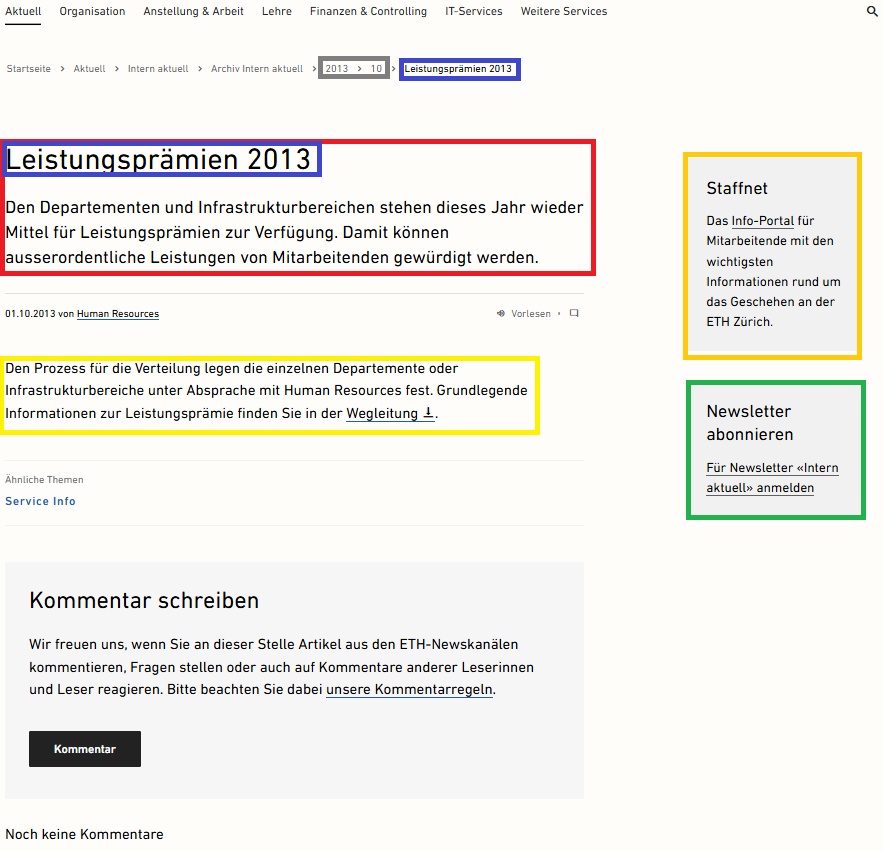


For example, `doc_id = f7af...` shows that all recognized lines turned out to be boilerplate or disclaimers (e.g., “Staffnet,” “Newsletter abonnieren”) and were removed in the advanced-cleaning stage.

**Html-file**:

```html
<div class="text-image cq-dd-image">
<p>Den Prozess für die Verteilung legen die einzelnen Departemente oder Infrastrukturbereiche unter Absprache mit Human Resources fest. Grundlegende Informationen zur Leistungsprämie finden Sie in der <a class="eth-link" href="/content/dam/ethz/associates/services/Anstellung-Arbeiten/Downloads/files/infos/Merkblatt_Leistungspraemie.pdf" target="_blank"><span class="eth-link__label">Download</span>Wegleitung (PDF, 34 KB)<span aria-hidden="true" class="material-icons">vertical_align_bottom</span></a>.<br/> </p>
</div>
<div class="text-image cq-dd-image">
<h2>Staffnet</h2>
<p>Das <a class="eth-link" href="https://ethz.ch/services/de.html">Info-Portal</a> für Mitarbeitende mit den wichtigsten Informationen rund um das Geschehen an der ETH Zürich.</p>
</div>
<div class="text-image cq-dd-image">
<h2>Newsletter abonnieren</h2>
<p><a class="eth-link" href="/staffnet/de/news-und-veranstaltungen/intern-aktuell/newsletter.html">Für Newsletter «Intern aktuell» anmelden</a>  </p>
</div>
```

**Raw/BeautifulSoup** extraction had some text:
```json
{
  "filename": "leistungspraemien-2013.html",
  "raw_text": "Den Prozess für die Verteilung legen die einzelnen Departemente oder Infrastrukturbereiche unter Absprache mit Human Resources fest. Grundlegende Informationen zur Leistungsprämie finden Sie in der\nDownload\nWegleitung (PDF, 34 KB)\nvertical_align_bottom\n.\nStaffnet\nDas\nInfo-Portal\nfür Mitarbeitende mit den wichtigsten Informationen rund um das Geschehen an der ETH Zürich.\nNewsletter abonnieren\nFür Newsletter «Intern aktuell» anmelden",
  "paragraphs": [
    "Den Prozess für die...", ...,],
  "doc_id": "f7af..."
}
```

In the second step, disclaimers (like “Staffnet,” “Newsletter abonnieren”) and repeated lines are systematically removed. As a result, main_content becomes empty, and `paragraphs_cleaned` is an empty list, indicating that all lines were identified as worthless boilerplate. Further metadata such as `named_entities` or `keywords` also remains empty.

In [ ]:
# 2) Demo empty paragraphs_cleaned
demo_empty_pars_cleaned(subsets_adv, data_hybrid_map)


------------- 2) empty_pars_cleaned -------------
Example doc_id from empty_pars_cleaned: f7af0912557c14c943098448c45563238047308f

--- Hybrid (or older step) record for same doc_id ---

{'doc_id': 'f7af0912557c14c943098448c45563238047308f',
 'filename': 'leistungspraemien-2013.html',
 'paragraphs': ['## Staffnet',
                'Das Info-Portal für Mitarbeitende mit den wichtigsten '
                'Informationen rund um das Geschehen an der ETH Zürich.',
                '## Newsletter abonnieren',
                'Für Newsletter «Intern aktuell» anmelden'],
 'raw_text': '## Staffnet\n'
             'Das Info-Portal für Mitarbeitende mit den wichtigsten '
             'Informationen rund um das Geschehen an der ETH Zürich.\n'
             '## Newsletter abonnieren\n'
             'Für Newsletter «Intern aktuell» anmelden'}

--- Advanced-cleaned record with empty paragraphs_cleaned ---

{
  "doc_id": "f7af0912557c14c943098448c45563238047308f",
  "filename": "leistungspraemien-2013.

Because this record has no meaningful content (no paragraphs, zero word count, empty `main_content`), it offers no value for indexing or retrieval. Accordingly, the validation step flags it for removal. The result is a cleaner overall dataset where each retained item actually contains text that might be relevant for subsequent chunking or retrieval tasks.

**Documents that have no `named_entities` but do have `main_content`**

Not every document has names or organizations that we can detect as entities, but still can contain real text. So a record might pass the “content” check (it isn’t empty) yet simply have no recognized named entities. This is not necessarily a removal reason—these documents may be kept if they have enough main_content, but we do note that `named_entities` is empty.

In [ ]:
# 3) Demo no named_entities but main_content
demo_no_entities_but_content(subsets_adv, data_hybrid_map)


------------- 3) no_entities_but_content -------------
Example doc_id from no_entities_but_content: 9dc64863c7b849d299d4d3f9d5d316952bfa0c2c

--- Hybrid (or older step) record for same doc_id ---

{'doc_id': '9dc64863c7b849d299d4d3f9d5d316952bfa0c2c',
 'filename': 'neue-arealplaene-fuer-die-eth-zuerich.html',
 'paragraphs': ['## Hinweis',
                'Ab 1. Januar 2016 werden die bisherigen Infrastrukturbereiche '
                'als Abteilungen geführt.',
                '## Staffnet',
                'Das Info-Portal für Mitarbeitende mit den wichtigsten '
                'Informationen rund um das Geschehen an der ETH Zürich.',
                '## Newsletter abonnieren',
                'Für Newsletter «Intern aktuell» anmelden'],
 'raw_text': '## Hinweis\n'
             'Ab 1. Januar 2016 werden die bisherigen Infrastrukturbereiche '
             'als Abteilungen geführt.\n'
             '## Staffnet\n'
             'Das Info-Portal für Mitarbeitende mit den wichtigsten '
   

After running the validation checks, we apply the following rules:
- Documents with empty `paragraphs_cleaned` are removed, since they provide no meaningful content after filtering.
- **Note**: Documents that have no `named_entities` but still contain valid `main_content` and `paragraphs_cleaned` are kept, as they can still hold valuable text despite not referencing specific entities.

We apply the `python Code/step_1_3_validation_filter.py` (see: [link](https://github.com/andrigerber/Adv_GenAI/blob/main/Code/step_1_3_validation_filter.py)) which takes the `BSD_advanced` folder and writes the valid records to a new folder called `BSD_advanced_validated`. This folder will contain only those records that passed validation and are ready for further processing.

Run the following command to filter the records:
```bash
python Code/step_1_3_validation_filter.py data_cleaned/BSD_advanced data_cleaned/BSD_advanced_validated
```
Now we check the final records in the `BSD_advanced_validated` folder and as expected the number of records is reduced to 3,546.

In [ ]:
# Now we check the final records in the `BSD_advanced_validated` folder.
data_dir_BSD_validated = Path("../data_cleaned/BSD_advanced_validated")
# 1) Load the records from the new validated folder
final_records = load_advanced_outputs(data_dir_BSD_validated)
# 2) Run the same validation logic
valid_records_check, df_stats_check, df_field_summary_check = validate_and_report(final_records)
# 3) Inspect results
# print("Validation results for final records in BSD_advanced_validated:\n")
# print(df_stats_check["kept_or_removed"].value_counts())
# print("\nField-level summary:")
# display(df_field_summary_check)
# Check the fields

INFO: Kept 3544 valid records; removed 0 invalid.


These final records are then appropriate for subsequent tasks such as chunking, specific preprocessing for retrieval, vector embedding or QA pipline steps.

---

# [Skripts](https://github.com/andrigerber/Adv_GenAI/tree/main/Code):

- [step_1_BeautifulSoup.py](https://github.com/andrigerber/Adv_GenAI/blob/main/Code/step_1_BeautifulSoup.py)
- [step_1_Docling.py](https://github.com/andrigerber/Adv_GenAI/blob/main/Code/step_1_Docling.py)
- [step_1_hybrid.py](https://github.com/andrigerber/Adv_GenAI/blob/main/Code/step_1_hybrid.py)
- [step_1_2_advanced_cleaning_and_metadata.py](https://github.com/andrigerber/Adv_GenAI/blob/main/Code/step_1_2_advanced_cleaning_and_metadata.py)
- [step_1_3_validation_filter.py](https://github.com/andrigerber/Adv_GenAI/blob/main/Code/step_1_3_validation_filter.py)
